### C3M10: Data Cleaning Pt. 1

## Data Preparation and Cleaning

General principles for starting work on a data set:

1)  Get the data
2)  Observe a few rows (observations)
3)  Get the dimensions of the dataset (how many observations, how many variables)
4)  Get the know the variables - data types, range of values, missing values
5)  Reduce the dataset to variables and observations of interest
6)  Make plots / tables of variables of interest to look for outliers, problems, etc.
7)  Start analysis . .
...

117)  Clean the data more when you discover problems!
118)  More Analysis

## CASE STUDY for today

We will look at data from [National Water quality Monitoring Council](https://www.waterqualitydata.us/).  
In particular, I downloaded Physical Chemistry measurements from Hartford County, CT.

What follows is also an example of one solution to dealing with large datasets.  The entire dataset is about 200MB which is larger than most file sharing locations allow.  I divided the data into 10 pieces, each about 20MB, read in the data, and then recombined into a single datasetset.


In [1]:
#This is to set global options so we can actually see all columns of a dataset when we ask for them
options(repr.matrix.max.cols = 150, repr.matrix.max.rows = 200)
library(dplyr)
library(ggplot2)



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
#get data files
water0 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_0.csv", header = T)
water1 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_1.csv", header = T)
water2 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_2.csv", header = T)
water3 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_3.csv", header = T)
water4 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_4.csv", header = T)
water5 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_5.csv", header = T)
water6 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_6.csv", header = T)
water7 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_7.csv", header = T)
water8 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_8.csv", header = T)
water9 <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/PhysChemHartford_9.csv", header = T)
head(water0)

,X,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime.Time,ActivityStartTime.TimeZoneCode,ActivityConductingOrganizationText,MonitoringLocationIdentifier,ActivityCommentText,SampleAquifer,HydrologicCondition,HydrologicEvent,ActivityLocation.LatitudeMeasure,SampleCollectionMethod.MethodIdentifier,SampleCollectionMethod.MethodIdentifierContext,SampleCollectionMethod.MethodName,SampleCollectionMethod.MethodDescriptionText,SampleCollectionEquipmentName,ResultIdentifier,ResultDetectionConditionText,MethodSpeciationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure.MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultCommentText,USGSPCode,ResultAnalyticalMethod.MethodIdentifier,ResultAnalyticalMethod.MethodIdentifierContext,ResultAnalyticalMethod.MethodName,ResultAnalyticalMethod.MethodUrl,ResultAnalyticalMethod.MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure.MeasureValue,DetectionQuantitationLimitMeasure.MeasureUnitCode
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>
1,1,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699249,,NA,"Temperature, water",,12,deg C,NA,Historical,,Actual,,,,,10,,,,NA,,,,,NA,,NA,
2,2,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699250,,NA,Flow rate,,1,gal/min,NA,Historical,,Actual,,,,,58,,,,NA,,,,,NA,,NA,
3,3,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699251,,NA,Specific conductance,Total,124,uS/cm @25C,NA,Historical,,Actual,,,25 deg C,,95,,,,NA,,,,,NA,,NA,
4,4,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699252,,NA,"Acidity, (H+)",Total,0.00003,mg/l,NA,Historical,,Actual,,,,,191,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,,NA,
5,5,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699253,,NA,pH,Total,7.6,std units,NA,Historical,,Actual,,,,,400,,,,NA,,,,,NA,,NA,
6,6,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699254,,NA,Carbon dioxide,Total,1.3,mg/l,NA,Historical,,Actual,,,,,405,,,,NA,,,,,NA,,NA,


In [3]:
#Make the final dataset
water <- rbind(water0, water1, water2, water3, water4, water5, water6, water7, water8, water9)

In [4]:
#How big is the dataset?
dim(water)

#What are the variable names?
names(water)

#Look at the first few rows
head(water)

[1] 409495     47

[1] "X"                                                
 [2] "ActivityTypeCode"                                 
 [3] "ActivityMediaName"                                
 [4] "ActivityMediaSubdivisionName"                     
 [5] "ActivityStartDate"                                
 [6] "ActivityStartTime.Time"                           
 [7] "ActivityStartTime.TimeZoneCode"                   
 [8] "ActivityConductingOrganizationText"               
 [9] "MonitoringLocationIdentifier"                     
[10] "ActivityCommentText"                              
[11] "SampleAquifer"                                    
[12] "HydrologicCondition"                              
[13] "HydrologicEvent"                                  
[14] "ActivityLocation.LatitudeMeasure"                 
[15] "SampleCollectionMethod.MethodIdentifier"          
[16] "SampleCollectionMethod.MethodIdentifierContext"   
[17] "SampleCollectionMethod.MethodName"                
[18] "SampleCollectionMethod.MethodDescriptionText"     
[19] "SampleCollectionEquipmentName"                    
[20] "ResultIdentifier"                                 
[21] "ResultDetectionConditionText"                     
[22] "MethodSpeciationName"                             
[23] "CharacteristicName"                               
[24] "ResultSampleFractionText"                         
[25] "ResultMeasureValue"                               
[26] "ResultMeasure.MeasureUnitCode"                    
[27] "MeasureQualifierCode"                             
[28] "ResultStatusIdentifier"                           
[29] "StatisticalBaseCode"                              
[30] "ResultValueTypeName"                              
[31] "ResultWeightBasisText"                            
[32] "ResultTimeBasisText"                              
[33] "ResultTemperatureBasisText"                       
[34] "ResultCommentText"                                
[35] "USGSPCode"                                        
[36] "ResultAnalyticalMethod.MethodIdentifier"          
[37] "ResultAnalyticalMethod.MethodIdentifierContext"   
[38] "ResultAnalyticalMethod.MethodName"                
[39] "ResultAnalyticalMethod.MethodUrl"                 
[40] "ResultAnalyticalMethod.MethodDescriptionText"     
[41] "LaboratoryName"                                   
[42] "AnalysisStartDate"                                
[43] "ResultLaboratoryCommentText"                      
[44] "ResultDetectionQuantitationLimitUrl"              
[45] "DetectionQuantitationLimitTypeName"               
[46] "DetectionQuantitationLimitMeasure.MeasureValue"   
[47] "DetectionQuantitationLimitMeasure.MeasureUnitCode"

,X,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime.Time,ActivityStartTime.TimeZoneCode,ActivityConductingOrganizationText,MonitoringLocationIdentifier,ActivityCommentText,SampleAquifer,HydrologicCondition,HydrologicEvent,ActivityLocation.LatitudeMeasure,SampleCollectionMethod.MethodIdentifier,SampleCollectionMethod.MethodIdentifierContext,SampleCollectionMethod.MethodName,SampleCollectionMethod.MethodDescriptionText,SampleCollectionEquipmentName,ResultIdentifier,ResultDetectionConditionText,MethodSpeciationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure.MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultCommentText,USGSPCode,ResultAnalyticalMethod.MethodIdentifier,ResultAnalyticalMethod.MethodIdentifierContext,ResultAnalyticalMethod.MethodName,ResultAnalyticalMethod.MethodUrl,ResultAnalyticalMethod.MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure.MeasureValue,DetectionQuantitationLimitMeasure.MeasureUnitCode
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>
1,1,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699249,,NA,"Temperature, water",,12,deg C,NA,Historical,,Actual,,,,,10,,,,NA,,,,,NA,,NA,
2,2,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699250,,NA,Flow rate,,1,gal/min,NA,Historical,,Actual,,,,,58,,,,NA,,,,,NA,,NA,
3,3,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699251,,NA,Specific conductance,Total,124,uS/cm @25C,NA,Historical,,Actual,,,25 deg C,,95,,,,NA,,,,,NA,,NA,
4,4,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699252,,NA,"Acidity, (H+)",Total,0.00003,mg/l,NA,Historical,,Actual,,,,,191,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,,NA,
5,5,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699253,,NA,pH,Total,7.6,std units,NA,Historical,,Actual,,,,,400,,,,NA,,,,,NA,,NA,
6,6,Sample-Routine,Water,Groundwater,3/21/1972,,,,USGS-414942072552101,,Non-Carbonate Crystalline Bedrock,Not determined,Routine sample,NA,USGS,USGS,USGS,NA,Unknown,NWIS-66699254,,NA,Carbon dioxide,Total,1.3,mg/l,NA,Historical,,Actual,,,,,405,,,,NA,,,,,NA,,NA,


There are lots of directions we could go.

Things I noticed about the variables upon first inspection:
 
1)  Information on location, time, method, organization related to the collection
2)  Information on type of collection and conditions of collection
3)  Information on multiple characteristics (one per row - Temperature, Salinity, etc.)

LOTS of data here.  One of the first things to do is focus on data of interest.

I decided to start reducing by focusing on the following:

* Dates between year 2000 and the present
* Focus on a few water quality characteristics

**SO** - first we need to identify and clean dates.  It appears we have a variable called "ActivityStartDate"

In [5]:
#check out a few values
water$ActivityStartDate[1:100]

#What is the variable type?
typeof(water$ActivityStartDate)

[1] "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972" 
  [6] "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972" 
 [11] "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972" 
 [16] "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972" 
 [21] "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972"  "3/21/1972" 
 [26] "3/21/1972"  "3/21/1972"  "3/21/1972"  "12/17/1974" "12/17/1974"
 [31] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [36] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [41] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [46] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [51] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [56] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [61] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [66] "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974" "12/17/1974"
 [71] "12/17/1974" "12/17/1974" "12/17/1974" "10/13/1971" "10/13/1971"
 [76] "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971"
 [81] "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971"
 [86] "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971"
 [91] "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971"
 [96] "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971" "10/13/1971"

[1] "character"

We will need to convert this to type 'Date'.  There are several ways to do this - here is one using `as.Date()`.

In [6]:
# Make a new column that is in date format using as.Date
water$date <- as.Date(water$ActivityStartDate, format = "%m/%d/%Y")

#Check structure
str(water$date)

# Get the range (min and max dates)
range(water$date)

 Date[1:409495], format: "1972-03-21" "1972-03-21" "1972-03-21" "1972-03-21" "1972-03-21" ...


[1] "1915-06-16" "2024-03-06"

Range is 1915 to 2024.  We make `water2` which has data from 2000 to the present.

In [7]:
#Make a new dataset called water2 that is our reduced version.  We choose rows that meet the condition outlined.
water2 <- water[water$date  > "2000-01-01", ]

#get new dimensions
dim(water2)

#confirm we got the correct dates
range(water2$date)


[1] 211873     48

[1] "2000-01-11" "2024-03-06"

**NEXT** - we examine what water characteristics are available. I am guessing in our list of variables that we want "CharacteristicName".

In [9]:
#What is the data type of Characteristic Name?
typeof(water2$CharacteristicName)

#What are unique values and how often to they occur?
#table(water2$CharacteristicName)
table(water2$CharacteristicName)[1:10]

[1] "character"


                                          (1R,2S,5R)-Menthol 
                                                          14 
                                            (E)-Dimethomorph 
                                                          17 
                                            (Z)-Dimethomorph 
                                                          17 
.alpha.-1,2,3,4,5,6-Hexachlorocyclohexane-D6 or alpha-HCH D6 
                                                         186 
                                          .alpha.-Endosulfan 
                                                          80 
                               .alpha.-Hexachlorocyclohexane 
                                                          90 
                                           .alpha.-Terpineol 
                                                           8 
                                           .beta.-Endosulfan 
                                                          17 
       

This is a great example of discovering a complicated mess and then making updates.

Let's get a list of unique Physical/Chemical characteristics that exist.

In [10]:
#Get unique values
#sort(unique(water2$CharacteristicName))
sort(unique(water2$CharacteristicName))[1:20]
#How long is this list?
length(unique(water2$CharacteristicName))


[1] "(1R,2S,5R)-Menthol"                                          
 [2] "(E)-Dimethomorph"                                            
 [3] "(Z)-Dimethomorph"                                            
 [4] ".alpha.-1,2,3,4,5,6-Hexachlorocyclohexane-D6 or alpha-HCH D6"
 [5] ".alpha.-Endosulfan"                                          
 [6] ".alpha.-Hexachlorocyclohexane"                               
 [7] ".alpha.-Terpineol"                                           
 [8] ".beta.-Endosulfan"                                           
 [9] ".beta.-Sitosterol"                                           
[10] ".lambda.-Cyhalothrin"                                        
[11] "1-(3,4-dichlorophenyl)-3-methyl urea"                        
[12] "1-Bromo-3-chloropropane-d6"                                  
[13] "1-Butanol"                                                   
[14] "1-Methoxy-4-(2-propenyl)benzene"                             
[15] "1-Methylnaphthalene"                                         
[16] "1-Naphthol"                                                  
[17] "1-Octanol"                                                   
[18] "1,1-Dichloroethane"                                          
[19] "1,1-Dichloroethene"                                          
[20] "1,1-Dichloropropanone"

[1] 924

This is still a lot to digest.  What are the 20 most commonly measured characteristics?

In [12]:
sort(table(water2$CharacteristicName), decreasing = T)[1:20]


                                      Total dissolved solids 
                                                        6554 
Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3) 
                                                        4744 
                                                      Oxygen 
                                                        4475 
                                              Orthophosphate 
                                                        4336 
                                        Ammonia and ammonium 
                                                        4331 
                                                     Nitrate 
                                                        4328 
                                                     Nitrite 
                                                        4328 
                                  Stream flow, instantaneous 
                                                        4224 
       

I was curious how many types of measurements contained "Nitr" or "nitr".  Remember, R is case sensitive.

A cool function to see if a word is contained in a text character is 'grep()'.

In [13]:
#example of grep
quickvec <- c("Airplane", "airplane", "boat", "air", "Hair", "zebra")
grep("air", quickvec)



[1] 2 4 5

In [14]:
#look for uppercase as well - remember that | means 'or'
grep("air|Air", quickvec)

#This can also be done by making all lowercase using the tolower() function
tolower(quickvec)
grep("air", tolower(quickvec))

[1] 1 2 4 5

[1] "airplane" "airplane" "boat"     "air"      "hair"     "zebra"

[1] 1 2 4 5

Let's look for 'Nitr' now

In [15]:
#Look for Nitr or nitr
temp <- grep("Nitr|nitr", water2$CharacteristicName)
temp[1:100]
unique(water2$CharacteristicName[temp])

[1]  160  243  244  245  246  248  249  250  251  252  290  292  299  300  335
 [16]  336  337  338  340  341  342  343  344  386  387  404  405  406  407  409
 [31]  410  411  412  413  446  459  683  684  709  711  712  713  717  720  721
 [46]  738  739  740  741  743  744  745  746  747  785  787  794  795  956 1041
 [61] 1042 1043 1044 1046 1047 1048 1049 1050 1058 1059 1062 1063 1074 1075 1076
 [76] 1077 1079 1080 1081 1082 1083 1092 1093 1108 1109 1110 1111 1113 1114 1115
 [91] 1116 1117 1150 1163 1271 1311 1321 1429 1431 1432

[1] "Nitrobenzene-D5"                                                                                          
 [2] "Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)"                                             
 [3] "Organic Nitrogen"                                                                                         
 [4] "Nitrite"                                                                                                  
 [5] "Nitrate"                                                                                                  
 [6] "Kjeldahl nitrogen"                                                                                        
 [7] "Inorganic nitrogen (nitrate and nitrite)"                                                                 
 [8] "Nitrogen"                                                                                                 
 [9] "Benzenepropanenitrile, .alpha.-(cyclopropylcarbonyl)- 2-(methylsulfonyl)-.beta.- oxo-4-(trifluoromethyl)-"
[10] "Nitrogen-15/14 ratio"                                                                                     
[11] "Pentachloronitrobenzene"                                                                                  
[12] "Particulate nitrogen/particulate organic carbon"                                                          
[13] "Acrylonitrile"                                                                                            
[14] "Methacrylonitrile"                                                                                        
[15] "Nitrobenzene"                                                                                             
[16] "Acetonitrile"                                                                                             
[17] "2-Nitropropane"                                                                                           
[18] "N-Nitrosodiethylamine"

Back to data reduction:   I decide to focus on three characteristics for the moment: 

* Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)
* Temperature, water
* Oxygen

Let's updated our dataset to include only rows that correspond to these measurements:

In [16]:
#Make a list of retained characteristics
charVec <- c("Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",
             "Temperature, water",
             "Oxygen")

#update water 2 to contain only rows that match this characteristic
water2 <- water2[water2$CharacteristicName %in% charVec, ]
dim(water2)

[1] 11471    48

We're down to 11k observations from > 400k.

We start by making a dataset that just has the information about Nitrogen.

In [20]:
#Make a dataset that is just nitrogen values
nitrogen <- water2[water2$CharacteristicName == "Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)", ]
dim(nitrogen)
#Note this is same value we saw in table before

[1] 4744   48

Which column has the actual measured values of nitrogen?

In [21]:
#names(nitrogen)
head(nitrogen, 4)
names(nitrogen)
nitrogen$ResultMeasureValue[1:100]

,X,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime.Time,ActivityStartTime.TimeZoneCode,ActivityConductingOrganizationText,MonitoringLocationIdentifier,ActivityCommentText,SampleAquifer,HydrologicCondition,HydrologicEvent,ActivityLocation.LatitudeMeasure,SampleCollectionMethod.MethodIdentifier,SampleCollectionMethod.MethodIdentifierContext,SampleCollectionMethod.MethodName,SampleCollectionMethod.MethodDescriptionText,SampleCollectionEquipmentName,ResultIdentifier,ResultDetectionConditionText,MethodSpeciationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure.MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultCommentText,USGSPCode,ResultAnalyticalMethod.MethodIdentifier,ResultAnalyticalMethod.MethodIdentifierContext,ResultAnalyticalMethod.MethodName,ResultAnalyticalMethod.MethodUrl,ResultAnalyticalMethod.MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure.MeasureValue,DetectionQuantitationLimitMeasure.MeasureUnitCode,date
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>,<date>
19699,19699,Sample-Routine,Water,Surface Water,9/27/2016,10:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,Falling stage,Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956180,,NA,"Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",Total,1.9,mg/l,NA,Accepted,,Actual,,,,,600,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,,NA,,2016-09-27
19700,19700,Sample-Routine,Water,Surface Water,9/27/2016,10:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,Falling stage,Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956181,,NA,"Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",Dissolved,1.6,mg/l,NA,Accepted,,Actual,,,,,602,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,,NA,,2016-09-27
19748,19748,Sample-Routine,Water,Surface Water,9/27/2016,10:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,Falling stage,Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956230,,NA,"Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",Dissolved,1.67,mg/l,NA,Accepted,,Actual,,,,,62854,CL063,USGS,"Nutrients, wf, FCC,persulfate,CF",NA,USGS WRI 03-4174,"USGS-National Water Quality Lab, Denver, CO",10/3/2016,,NA,Detection limit by DQCALC,0.05,mg/l,2016-09-27
19791,19791,Sample-Routine,Water,Surface Water,2/18/2016,8:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01189030,,,"Stable, high stage",Routine sample,NA,30,USGS parameter code 82398,"Single vertical, depth integrated",NA,US DH-95 plastic bottle,NWIS-103361718,,NA,"Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",Total,1.5,mg/l,NA,Accepted,,Actual,,,,,600,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,,NA,,2016-02-18


[1] "X"                                                
 [2] "ActivityTypeCode"                                 
 [3] "ActivityMediaName"                                
 [4] "ActivityMediaSubdivisionName"                     
 [5] "ActivityStartDate"                                
 [6] "ActivityStartTime.Time"                           
 [7] "ActivityStartTime.TimeZoneCode"                   
 [8] "ActivityConductingOrganizationText"               
 [9] "MonitoringLocationIdentifier"                     
[10] "ActivityCommentText"                              
[11] "SampleAquifer"                                    
[12] "HydrologicCondition"                              
[13] "HydrologicEvent"                                  
[14] "ActivityLocation.LatitudeMeasure"                 
[15] "SampleCollectionMethod.MethodIdentifier"          
[16] "SampleCollectionMethod.MethodIdentifierContext"   
[17] "SampleCollectionMethod.MethodName"                
[18] "SampleCollectionMethod.MethodDescriptionText"     
[19] "SampleCollectionEquipmentName"                    
[20] "ResultIdentifier"                                 
[21] "ResultDetectionConditionText"                     
[22] "MethodSpeciationName"                             
[23] "CharacteristicName"                               
[24] "ResultSampleFractionText"                         
[25] "ResultMeasureValue"                               
[26] "ResultMeasure.MeasureUnitCode"                    
[27] "MeasureQualifierCode"                             
[28] "ResultStatusIdentifier"                           
[29] "StatisticalBaseCode"                              
[30] "ResultValueTypeName"                              
[31] "ResultWeightBasisText"                            
[32] "ResultTimeBasisText"                              
[33] "ResultTemperatureBasisText"                       
[34] "ResultCommentText"                                
[35] "USGSPCode"                                        
[36] "ResultAnalyticalMethod.MethodIdentifier"          
[37] "ResultAnalyticalMethod.MethodIdentifierContext"   
[38] "ResultAnalyticalMethod.MethodName"                
[39] "ResultAnalyticalMethod.MethodUrl"                 
[40] "ResultAnalyticalMethod.MethodDescriptionText"     
[41] "LaboratoryName"                                   
[42] "AnalysisStartDate"                                
[43] "ResultLaboratoryCommentText"                      
[44] "ResultDetectionQuantitationLimitUrl"              
[45] "DetectionQuantitationLimitTypeName"               
[46] "DetectionQuantitationLimitMeasure.MeasureValue"   
[47] "DetectionQuantitationLimitMeasure.MeasureUnitCode"
[48] "date"

[1] "1.9"  "1.6"  "1.67" "1.5"  "1.3"  "0.42" "0.45" "0.39" "3.32" "2.5" 
 [11] "2.2"  "2.27" "0.79" "0.72" "0.74" "0.5"  "0.56" "0.49" "0.37" "0.38"
 [21] "0.99" "0.32" "0.78" "0.74" "0.42" "0.37" "2.86" "2.87" "3.8"  "3.6" 
 [31] "2.42" "1.03" "0.94" "0.86" "0.85" "2.2"  "2.1"  "0.55" "0.53" "0.54"
 [41] "3.7"  "3.7"  "3.56" "0.52" "0.5"  "4.48" "0.68" "0.63" "0.6"  "0.6" 
 [51] "0.28" "0.26" "3.36" "4.1"  "3.9"  "0.83" "0.74" "0.81" "0.66" "0.68"
 [61] "5.5"  "5.2"  "5.37" "5.3"  "5.1"  "5.19" "3.3"  "3"    "1.1"  "0.97"
 [71] "0.5"  "0.44" "4.2"  "4.2"  "0.63" "0.56" "0.59" "0.51" "0.42" "0.44"
 [81] "0.79" "0.66" "4.67" "0.25" "0.24" "2.48" "0.64" "0.56" "0.6"  "1.01"
 [91] "0.47" "0.46" "0.44" "0.56" "0.52" "0.51" "1"    "0.94" "2.34" "4"

OK, so this is a character variable, not numeric.

Also, we better see if the units are all the same.

In [22]:
table(nitrogen$ResultMeasure.MeasureUnitCode)


     mg/l 
  55 4689 

This means that for 55 measurements, we don't know the units.  Let's look at the first few rows of the missing values.

In [23]:
nitrogen[nitrogen$ResultMeasure.MeasureUnitCode == "", ][1:3, ]


,X,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime.Time,ActivityStartTime.TimeZoneCode,ActivityConductingOrganizationText,MonitoringLocationIdentifier,ActivityCommentText,SampleAquifer,HydrologicCondition,HydrologicEvent,ActivityLocation.LatitudeMeasure,SampleCollectionMethod.MethodIdentifier,SampleCollectionMethod.MethodIdentifierContext,SampleCollectionMethod.MethodName,SampleCollectionMethod.MethodDescriptionText,SampleCollectionEquipmentName,ResultIdentifier,ResultDetectionConditionText,MethodSpeciationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure.MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultCommentText,USGSPCode,ResultAnalyticalMethod.MethodIdentifier,ResultAnalyticalMethod.MethodIdentifierContext,ResultAnalyticalMethod.MethodName,ResultAnalyticalMethod.MethodUrl,ResultAnalyticalMethod.MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure.MeasureValue,DetectionQuantitationLimitMeasure.MeasureUnitCode,date
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>,<date>
60025,60025,Sample-Routine,Water,Groundwater,8/21/2003,14:00:00,EDT,U.S. Geological Survey-Water Resources Discipline,USGS-414815072335701,A-2340176 3 drops of hcl added to gcv's,,Not applicable,Not applicable,NA,4040,USGS parameter code 82398,Submersible pump,NA,Submersible gear pump,NWIS-66209709,Not Detected,NA,"Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",Dissolved,NA,,NA,Accepted,,Actual,,NA,,,602,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,Historical Lower Reporting Limit,0.85,mg/l,2003-08-21
60451,60451,Sample-Routine,Water,Groundwater,8/8/2003,12:10:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-414555072333601,A-2230027 2 Drops of HCL added to GCV's L-2230027 recvd 8-9-03. Changed date from 7/2/2003 per dist (Lewis) 10/1/03 dm.,,Not applicable,Not applicable,NA,4040,USGS parameter code 82398,Submersible pump,NA,Submersible gear pump,NWIS-66204442,Not Detected,NA,"Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",Dissolved,NA,,NA,Accepted,,Actual,,NA,,,602,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,Historical Lower Reporting Limit,0.99,mg/l,2003-08-08
60993,60993,Sample-Routine,Water,Groundwater,8/4/2003,14:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-415446072364501,A-2180235 2 Drops of HCL added to GCV's L-2180235 LC4200 Added. Sample received cloudy. LC4200 Added. Sample received cloudy LC4200 Added. Sample received cloudy.,,Not applicable,Not applicable,NA,4040,USGS parameter code 82398,Submersible pump,NA,Submersible gear pump,NWIS-66200794,Not Detected,NA,"Nitrogen, mixed forms (NH3), (NH4), organic, (NO2) and (NO3)",Dissolved,NA,,NA,Accepted,,Actual,,NA,,,602,ALGOR,USGS,Computation by NWIS algorithm,NA,"NWIS User's Manual, QW System, Section 3.6.7",,,,NA,Historical Lower Reporting Limit,5.90,mg/l,2003-08-04


It looks like unusual things happened for these data points (see comments and note that all measurement values are missing)

Let's update nitrogen to exclude values with no units

In [24]:
nitrogen <- nitrogen[nitrogen$ResultMeasure.MeasureUnitCode != "", ]
dim(nitrogen)

[1] 4689   48

Back to nitrogen values which are character

In [25]:
head(sort(nitrogen$ResultMeasureValue))
tail(sort(nitrogen$ResultMeasureValue))

#Looks like they are all numbers, so we convert to numeric and add a new column with this data
nitrogen$Nitrogen <- as.numeric(nitrogen$ResultMeasureValue)
#Look at first 10 values
nitrogen$Nitrogen[1:10]

[1] "0.1"  "0.1"  "0.11" "0.11" "0.11" "0.12"

[1] "8.1" "8.4" "8.4" "8.5" "9.5" "9.8"

[1] 1.90 1.60 1.67 1.50 1.30 0.42 0.45 0.39 3.32 2.50

Let's get a quick look at nitrogen values

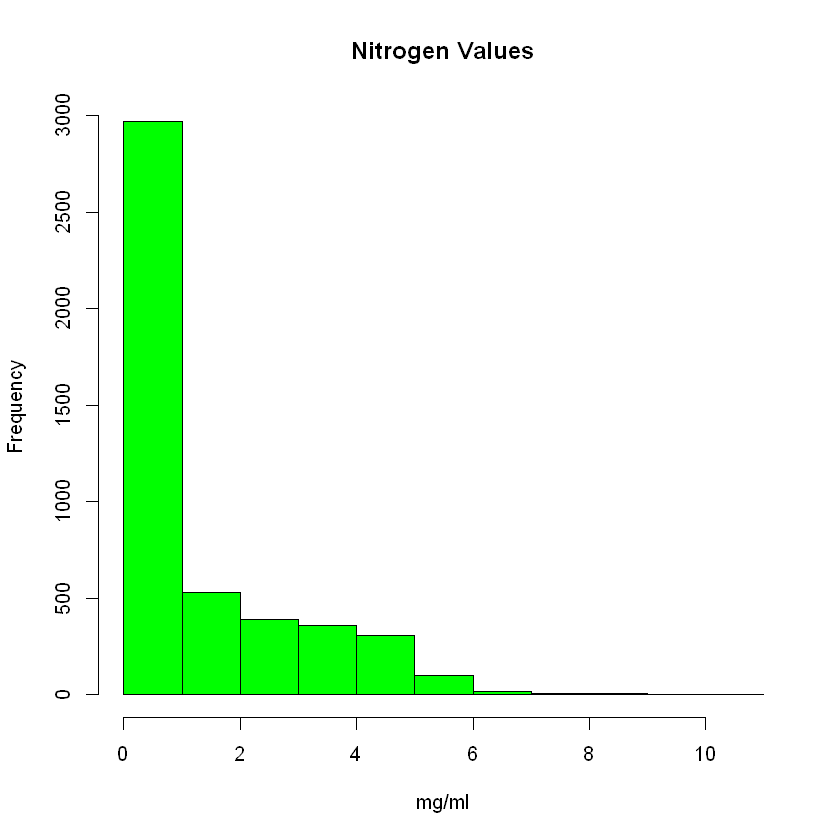

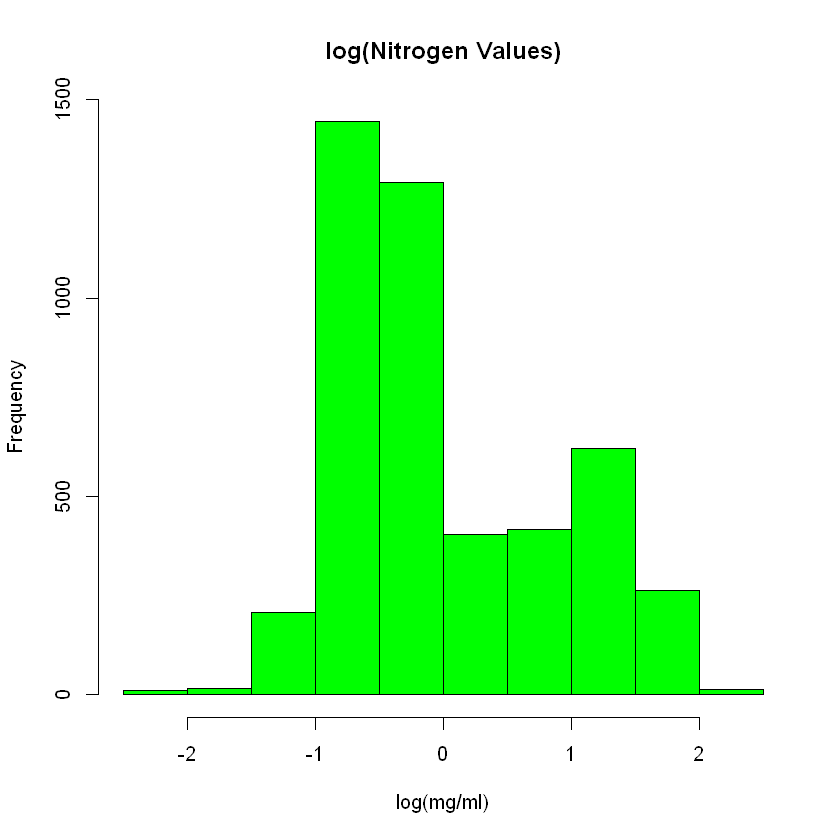

In [26]:
hist(nitrogen$Nitrogen, col = "Green",
     main = "Nitrogen Values",
     xlab = "mg/ml")

#Just out of curiosity, try log scale.  NOTE  - we didn't have zero values, but it is important to check this

hist(log(nitrogen$Nitrogen), col = "Green",
     main = "log(Nitrogen Values)",
     xlab = "log(mg/ml)")

Let's look at variables again - I was curious about Subdivision Name

In [27]:

table(nitrogen$ActivityMediaSubdivisionName)



  Groundwater Surface Water 
           64          4625 

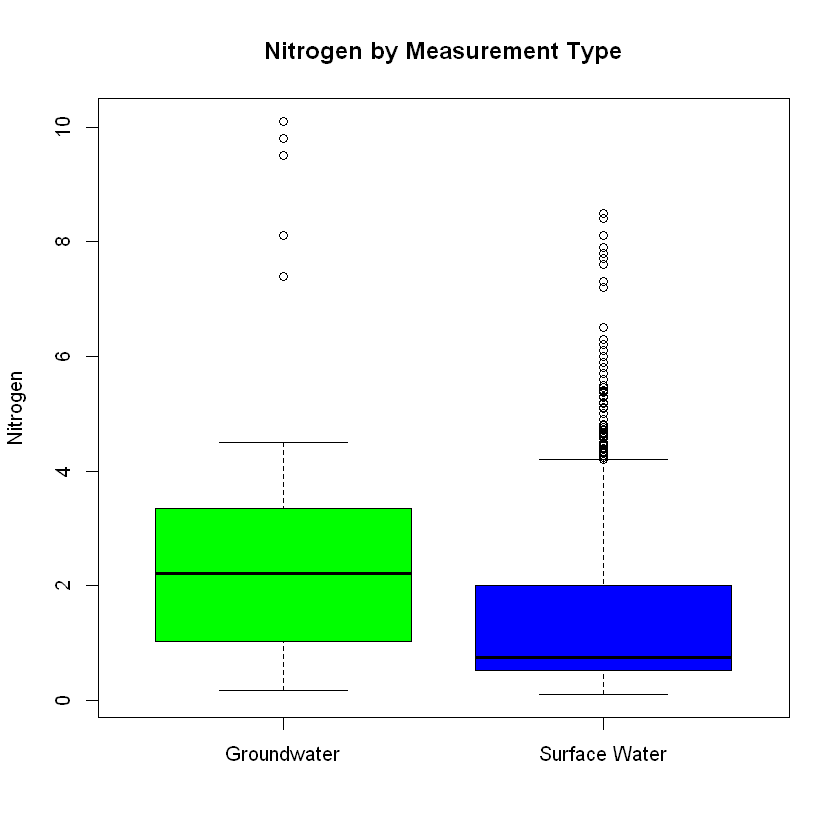

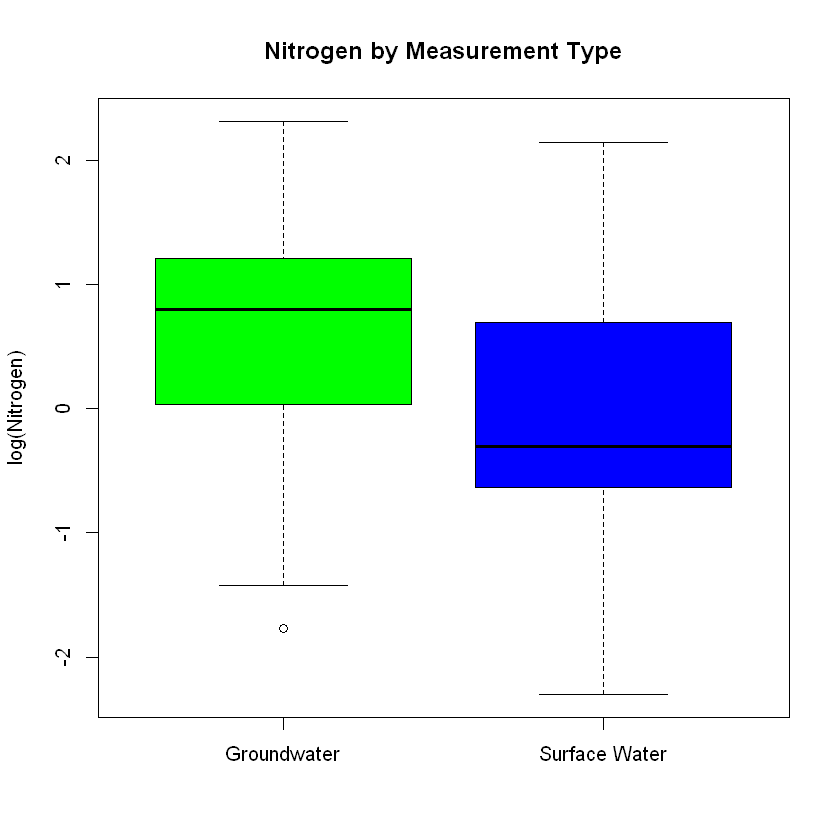

In [28]:
#Compare Groundwater to Surface Water, raw and log scale
boxplot(Nitrogen ~ ActivityMediaSubdivisionName, data = nitrogen,
        col = c("green", "blue"),
        xlab = "",
        main = "Nitrogen by Measurement Type")

boxplot(log(Nitrogen) ~ ActivityMediaSubdivisionName, data = nitrogen,
        col = c("green", "blue"),
        xlab = "",
        main = "Nitrogen by Measurement Type")

It appears that Groundwater values are generally higher.

I was concerned by two other columns:

* ResultSampleFractionText
* USGSPCode

I started by making a table of the levels and counts for each column

In [29]:
table(nitrogen$USGSPCode)
table(nitrogen$ResultSampleFractionText)


  600   602 62854 62855 
 2041  1961   596    91 


Dissolved     Total 
     2557      2132 

A quick google search  took me back to the original website where I discovered there is a site with United States Geological Survey Parameter codes (USGSP).  I looked up 'Nutrient Parameter Codes' and discovered on their [website](https://help.waterdata.usgs.gov/parameter_cd?group_cd=NUT) that 


*  600 is Total Nitrogen, used by the EPA

*  602 is Dissolved Nitrogen, used by the EPA

*  62854 is Dissolved but analytically determined, NOT used by the EPA

*  62855 is Total but analytically determined, NOT used by the EPA 

This is concerning in that it looks like I actually may be combining 4 different measurements together and pretending they are a single measurement.

Let's look at our boxplots again (log scale) by USGSPCode.


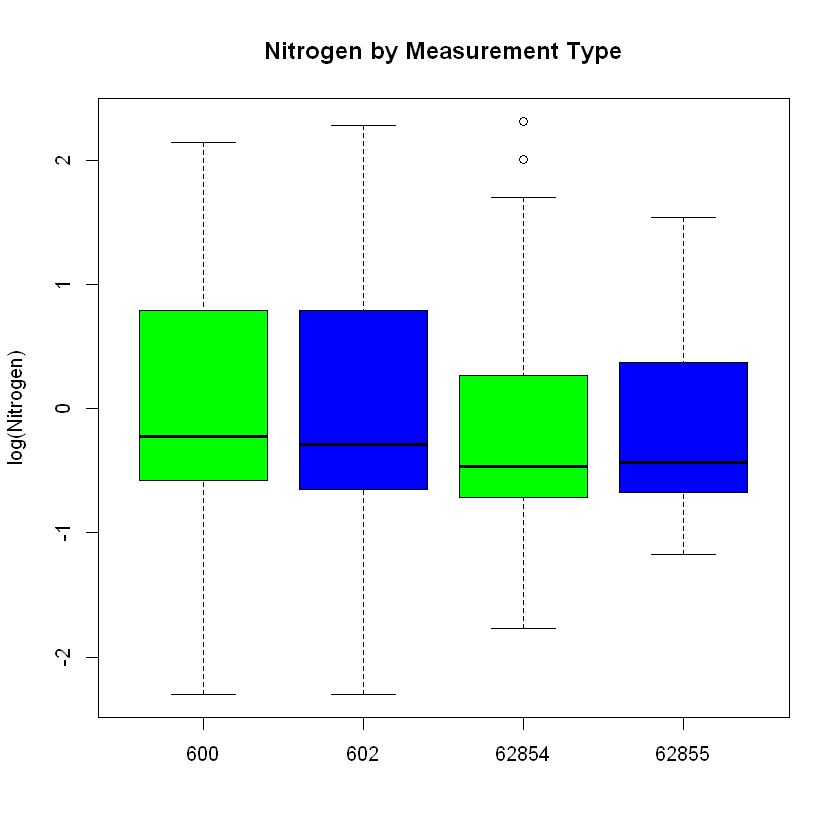

In [30]:
boxplot(log(Nitrogen) ~ USGSPCode, data = nitrogen,
        col = c("green", "blue"),
        xlab = "",
        main = "Nitrogen by Measurement Type")

Let's update nitrogen to JUST be total (not dissolved), and we'll remove groundwater

In [31]:
nitrogen <- nitrogen[nitrogen$ActivityMediaSubdivisionName != "Groundwater" & nitrogen$USGSPCode %in% c(600, 62855), ]
dim(nitrogen)

[1] 2132   49

NOW: we are finally ready to start looking at total nitrogen.
We start by looking at how nitrogen has changed over time.

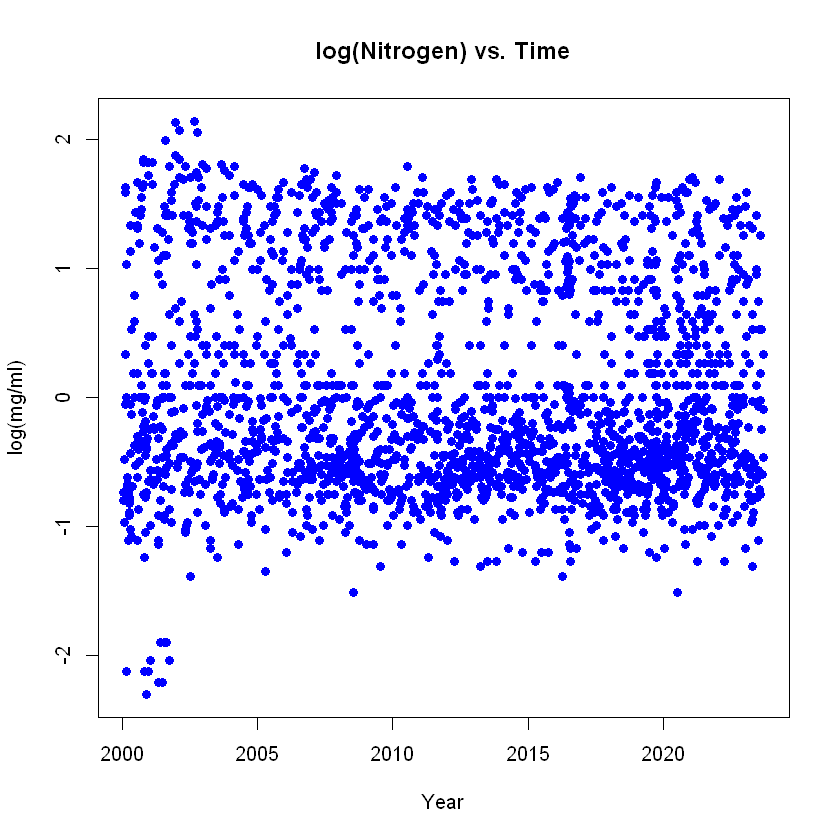

In [32]:
plot(log(nitrogen$Nitrogen) ~ nitrogen$date,
     col = "blue",
     pch = 19,
     main = "log(Nitrogen) vs. Time",
     xlab = "Year",
     ylab = "log(mg/ml)")

Seems as if there are two stripes.  This is interesting and maybe concerning (are there still two groups?)
What about looking at levels vs. month of year?  Maybe there is seasonality?

Here is example of how to use AI to get code:

Question: write r code that takes a variable in Date format and creates a new column that is date but in order of months from January through December


[1] September February  April     April     August    January   May      
 [8] March     June      July      April     January   July      May      
[15] December  August    July      December  April     September June     
[22] July      September October   March     July      June      July     
[29] July      February  December  February  August    February  October  
[36] June      March     November  August    July      April     July     
[43] June      June      August    June      June      June      October  
[50] September
12 Levels: January < February < March < April < May < June < ... < December

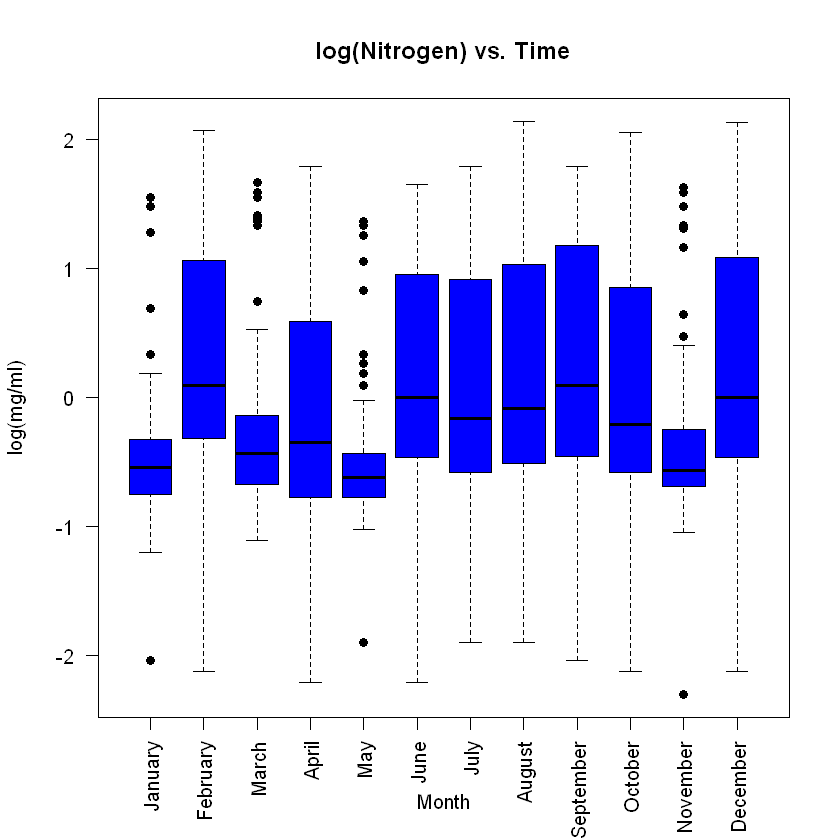

In [33]:
# Create a new column with month names ordered from January to December
nitrogen$month_ordered <- factor(format(nitrogen$date, "%B"),
                           levels = month.name,
                           ordered = TRUE)

#Look at first 50 values
nitrogen$month_ordered[1:50]

#Make new plot
boxplot(log(nitrogen$Nitrogen) ~ nitrogen$month_ordered,
     col = "blue",
     pch = 19,
     main = "log(Nitrogen) vs. Time",
     xlab = "Month",
     ylab = "log(mg/ml)",
     las = 2)

So it appears that the differences we were seeing were not due to month.

I invstigated further to see if this was related to Hydrologic Condition or Hydrologic Event.


In [34]:
table(nitrogen$HydrologicCondition)
table(nitrogen$HydrologicEvent)


       Falling stage       Not applicable       Not determined 
                 323                    1                   77 
          Peak stage         Rising stage   Stable, high stage 
                  11                  201                   88 
   Stable, low stage Stable, normal stage 
                 200                 1231 


         Flood Regulated flow Routine sample       Snowmelt          Storm 
             3           1108            860              1             92 
  Tidal action 
            68 

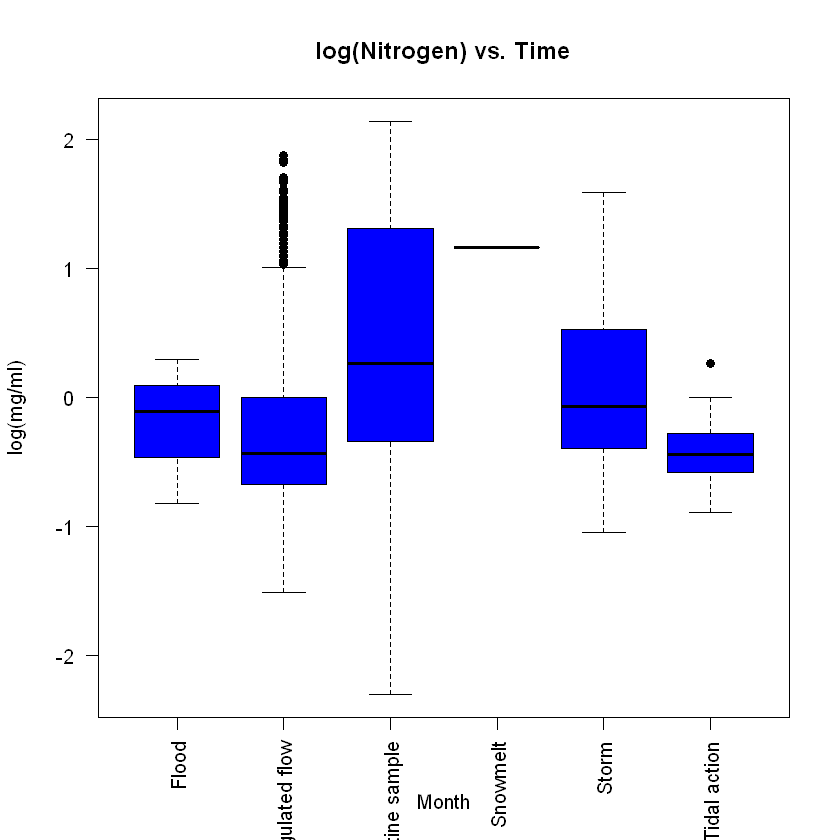

In [35]:
#Make new plot
boxplot(log(nitrogen$Nitrogen) ~ nitrogen$HydrologicEvent,
     col = "blue",
     pch = 19,
     main = "log(Nitrogen) vs. Time",
     xlab = "Month",
     ylab = "log(mg/ml)",
     las = 2)

It seems like this might be related to the bands that we're seeing in our scatterplot.

We update the scatterplot to use a different color for each Hydrologic Event.

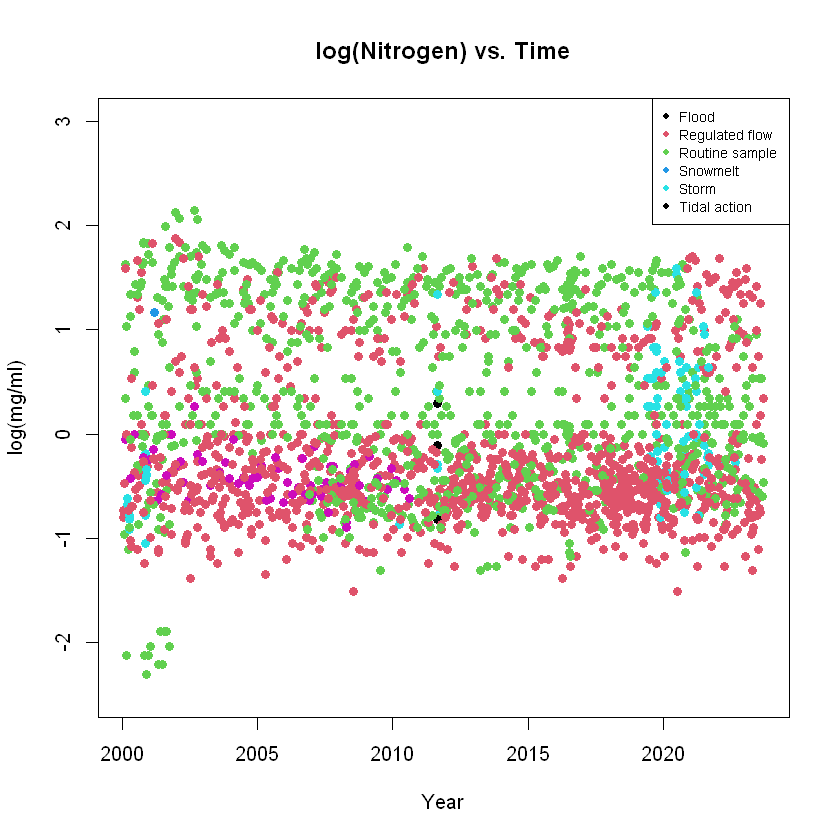

In [36]:
plot(log(Nitrogen) ~ date,
     data = nitrogen,
     col = as.factor(HydrologicEvent),
     pch = 19,
     main = "log(Nitrogen) vs. Time",
     xlab = "Year",
     ylab = "log(mg/ml)",
     ylim = c(-2.5, 3))
legend("topright", col = 1:5, legend =  levels(as.factor(nitrogen$HydrologicEvent)), pch = 19, cex = .7)

In [0]:
It looks like there might be some relationship here, but more investigation is required!


## Oxygen vs. Temperature
We now investigate the relationship between oxygen levels and water temperature.  It is well known that oxygen capacity decreases as temperature increases.

We'll need to make a new dataset with oxygen and temperature AND we need to then merge and make sure we're merging correctly.

From last time, I learned to check USGSP Codes!

* 300 is Dissolved oxygen, ml/l
* 301 is Dissolved oxygen, percent of saturation

We will use only dissolved oxygen in terms of ml/l.


In [37]:
#Make oxygen dataframe
oxygen <- water2[water2$CharacteristicName == "Oxygen" & water2$USGSPCode == 300, ]
dim(oxygen)
head(oxygen)

[1] 2248   48

,X,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime.Time,ActivityStartTime.TimeZoneCode,ActivityConductingOrganizationText,MonitoringLocationIdentifier,ActivityCommentText,SampleAquifer,HydrologicCondition,HydrologicEvent,ActivityLocation.LatitudeMeasure,SampleCollectionMethod.MethodIdentifier,SampleCollectionMethod.MethodIdentifierContext,SampleCollectionMethod.MethodName,SampleCollectionMethod.MethodDescriptionText,SampleCollectionEquipmentName,ResultIdentifier,ResultDetectionConditionText,MethodSpeciationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure.MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultCommentText,USGSPCode,ResultAnalyticalMethod.MethodIdentifier,ResultAnalyticalMethod.MethodIdentifierContext,ResultAnalyticalMethod.MethodName,ResultAnalyticalMethod.MethodUrl,ResultAnalyticalMethod.MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure.MeasureValue,DetectionQuantitationLimitMeasure.MeasureUnitCode,date
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>,<date>
19691,19691,Sample-Routine,Water,Surface Water,9/27/2016,10:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,Falling stage,Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956172,,NA,Oxygen,Dissolved,9.2,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-09-27
19766,19766,Quality Control Sample-Field Replicate,Water,Surface Water,9/28/2016,8:15:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01184490,,,Falling stage,Routine sample,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956139,,NA,Oxygen,Dissolved,8.8,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-09-28
19783,19783,Sample-Routine,Water,Surface Water,2/18/2016,8:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01189030,,,"Stable, high stage",Routine sample,NA,30,USGS parameter code 82398,"Single vertical, depth integrated",NA,US DH-95 plastic bottle,NWIS-103361710,,NA,Oxygen,Dissolved,13.1,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-02-18
19853,19853,Quality Control Sample-Field Replicate,Water,Surface Water,4/7/2016,10:10:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01184000,MM-46343A,,"Stable, normal stage",Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-95 Teflon bottle,NWIS-103632178,,NA,Oxygen,Dissolved,13,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-04-07
20186,20186,Quality Control Sample-Field Replicate,Water,Surface Water,8/24/2016,10:45:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,"Stable, normal stage",Regulated flow,NA,15,USGS parameter code 82398,"10 or more equal width verticals, equal non-iso transit rate limited by velocity",NA,US DH-81,NWIS-105601619,,NA,Oxygen,Dissolved,8.8,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-08-24
20494,20494,Sample-Routine,Water,Surface Water,1/13/2016,14:00:00,EST,U.S. Geological Surve

Now we need to find corresponding water temperature values

In [38]:
tempC <- water2[water2$CharacteristicName == "Temperature, water", ]
head(tempC)
#confirm all one USGSP code - the code we want is 10
table(tempC$USGSPCode)

dim(tempC)
dim(oxygen)

,X,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime.Time,ActivityStartTime.TimeZoneCode,ActivityConductingOrganizationText,MonitoringLocationIdentifier,ActivityCommentText,SampleAquifer,HydrologicCondition,HydrologicEvent,ActivityLocation.LatitudeMeasure,SampleCollectionMethod.MethodIdentifier,SampleCollectionMethod.MethodIdentifierContext,SampleCollectionMethod.MethodName,SampleCollectionMethod.MethodDescriptionText,SampleCollectionEquipmentName,ResultIdentifier,ResultDetectionConditionText,MethodSpeciationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure.MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultCommentText,USGSPCode,ResultAnalyticalMethod.MethodIdentifier,ResultAnalyticalMethod.MethodIdentifierContext,ResultAnalyticalMethod.MethodName,ResultAnalyticalMethod.MethodUrl,ResultAnalyticalMethod.MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure.MeasureValue,DetectionQuantitationLimitMeasure.MeasureUnitCode,date
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>,<date>
19686,19686,Sample-Routine,Water,Surface Water,9/27/2016,10:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,Falling stage,Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956164,,NA,"Temperature, water",,17.9,deg C,NA,Accepted,,Actual,,,,,10,THM01,USGS,"Temperature, water, thermistor",NA,"USGS National Field Manual, Chapter A6.1",U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-09-27
19759,19759,Quality Control Sample-Field Replicate,Water,Surface Water,9/28/2016,8:15:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01184490,,,Falling stage,Routine sample,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956131,,NA,"Temperature, water",,16.8,deg C,NA,Preliminary,,Actual,,,,,10,THM01,USGS,"Temperature, water, thermistor",NA,"USGS National Field Manual, Chapter A6.1",U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-09-28
19777,19777,Sample-Routine,Water,Surface Water,2/18/2016,8:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01189030,,,"Stable, high stage",Routine sample,NA,30,USGS parameter code 82398,"Single vertical, depth integrated",NA,US DH-95 plastic bottle,NWIS-103361703,,NA,"Temperature, water",,0.9,deg C,NA,Preliminary,,Actual,,,,,10,THM01,USGS,"Temperature, water, thermistor",NA,"USGS National Field Manual, Chapter A6.1",U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-02-18
19845,19845,Quality Control Sample-Field Replicate,Water,Surface Water,4/7/2016,10:10:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01184000,MM-46343A,,"Stable, normal stage",Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-95 Teflon bottle,NWIS-103632169,,NA,"Temperature, water",,5.4,deg C,NA,Preliminary,,Actual,,,,,10,THM01,USGS,"Temperature, water, thermistor",NA,"USGS National Field Manual, Chapter A6.1",U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-04-07
20179,20179,Quality Control Sample-Field Replicate,Water,Surface Water,8/24/2016,10:45:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,"Stable, normal stage",Regulated flow,NA,15,USGS parameter code 82398,"10 or more equal width verticals, equal non-iso transit rate limited by velocity",NA,US DH-81,NWIS-105601611,,NA,"Temperature, water",,22.3,deg C,NA,Accepted,,Actual,,,,,10,THM01,USGS,"Temperature, water, the


  10 
2252 

[1] 2252   48

[1] 2248   48

**NOW** - we want to merge these datasets together.

We will need to merge by data/time to make sure they match.  We'll also want to remove most other variables to keep things simpler.


In [39]:
head(oxygen)
oxygen <- oxygen[, c("ActivityStartDate", "ActivityStartTime.Time", "MonitoringLocationIdentifier", "ResultMeasureValue", "ActivityMediaSubdivisionName")]
oxygen <- oxygen |> rename(Oxygen = ResultMeasureValue)

tempC <- tempC[, c("ActivityStartDate", "ActivityStartTime.Time", "MonitoringLocationIdentifier", "ResultMeasureValue")]
tempC <- tempC |> rename(TempC = ResultMeasureValue)

dim(oxygen)
dim(tempC)

,X,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime.Time,ActivityStartTime.TimeZoneCode,ActivityConductingOrganizationText,MonitoringLocationIdentifier,ActivityCommentText,SampleAquifer,HydrologicCondition,HydrologicEvent,ActivityLocation.LatitudeMeasure,SampleCollectionMethod.MethodIdentifier,SampleCollectionMethod.MethodIdentifierContext,SampleCollectionMethod.MethodName,SampleCollectionMethod.MethodDescriptionText,SampleCollectionEquipmentName,ResultIdentifier,ResultDetectionConditionText,MethodSpeciationName,CharacteristicName,ResultSampleFractionText,ResultMeasureValue,ResultMeasure.MeasureUnitCode,MeasureQualifierCode,ResultStatusIdentifier,StatisticalBaseCode,ResultValueTypeName,ResultWeightBasisText,ResultTimeBasisText,ResultTemperatureBasisText,ResultCommentText,USGSPCode,ResultAnalyticalMethod.MethodIdentifier,ResultAnalyticalMethod.MethodIdentifierContext,ResultAnalyticalMethod.MethodName,ResultAnalyticalMethod.MethodUrl,ResultAnalyticalMethod.MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure.MeasureValue,DetectionQuantitationLimitMeasure.MeasureUnitCode,date
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>,<date>
19691,19691,Sample-Routine,Water,Surface Water,9/27/2016,10:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,Falling stage,Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956172,,NA,Oxygen,Dissolved,9.2,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-09-27
19766,19766,Quality Control Sample-Field Replicate,Water,Surface Water,9/28/2016,8:15:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01184490,,,Falling stage,Routine sample,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-81,NWIS-105956139,,NA,Oxygen,Dissolved,8.8,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-09-28
19783,19783,Sample-Routine,Water,Surface Water,2/18/2016,8:00:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01189030,,,"Stable, high stage",Routine sample,NA,30,USGS parameter code 82398,"Single vertical, depth integrated",NA,US DH-95 plastic bottle,NWIS-103361710,,NA,Oxygen,Dissolved,13.1,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-02-18
19853,19853,Quality Control Sample-Field Replicate,Water,Surface Water,4/7/2016,10:10:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01184000,MM-46343A,,"Stable, normal stage",Regulated flow,NA,40,USGS parameter code 82398,Multiple verticals,NA,US DH-95 Teflon bottle,NWIS-103632178,,NA,Oxygen,Dissolved,13,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-04-07
20186,20186,Quality Control Sample-Field Replicate,Water,Surface Water,8/24/2016,10:45:00,EST,U.S. Geological Survey-Water Resources Discipline,USGS-01192500,,,"Stable, normal stage",Regulated flow,NA,15,USGS parameter code 82398,"10 or more equal width verticals, equal non-iso transit rate limited by velocity",NA,US DH-81,NWIS-105601619,,NA,Oxygen,Dissolved,8.8,mg/l,NA,Accepted,,Actual,,,,,300,LUMIN,USGS,"Diss oxygen, luminescence sensor",NA,ASTM,U.S. Geological Survey-Water Resources Discipline,,,NA,,NA,,2016-08-24
20494,20494,Sample-Routine,Water,Surface Water,1/13/2016,14:00:00,EST,U.S. Geological Surve

[1] 2248    5

[1] 2252    4

In [40]:
#merge - by default, it will delete observations that are not in both datasets
newData <- merge(oxygen, tempC)
dim(newData)

[1] 2247    6

**GREAT**.  Now we can make a scatterplot.

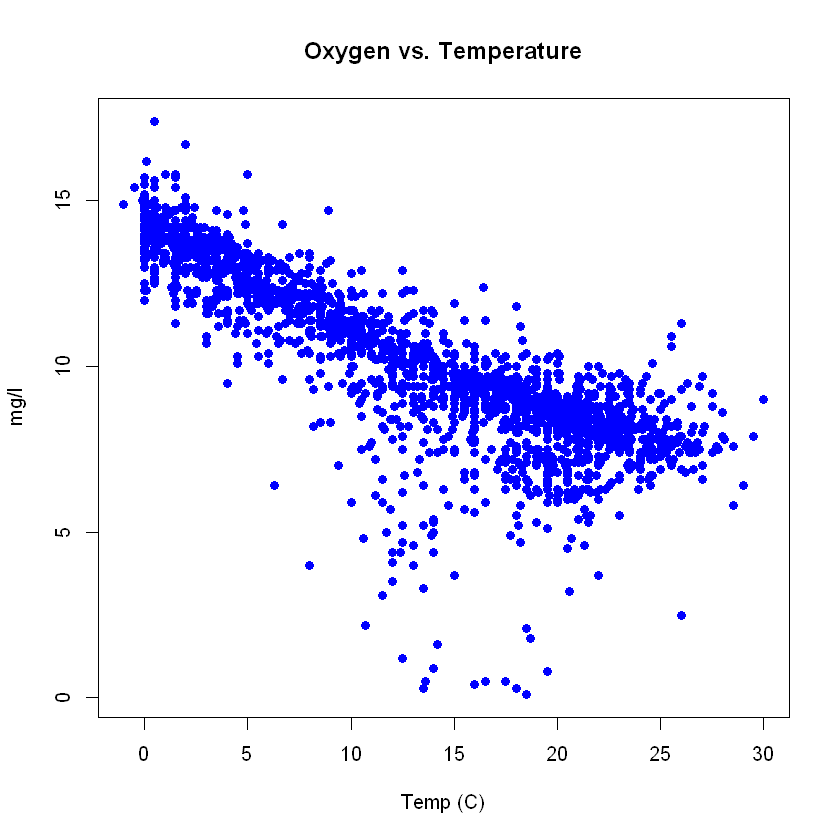

In [41]:
plot(Oxygen ~ TempC,
     data = newData,
     col = "blue",
     pch = 19,
     main = "Oxygen vs. Temperature",
     xlab = "Temp (C)",
     ylab = "mg/l")

I was curious about Oxygen levels of 5 or less. This made we wonder if some oxygen values were collected under a different condition.

Back to the oxygen data:

In [42]:
head(newData)
table(newData$ActivityMediaSubdivisionName)

,ActivityStartDate,ActivityStartTime.Time,MonitoringLocationIdentifier,Oxygen,ActivityMediaSubdivisionName,TempC
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1/10/2007,10:15:00,USGS-01188090,13,Surface Water,3.5
2,1/10/2007,8:15:00,USGS-01188000,13,Surface Water,2
3,1/11/2001,12:40:00,USGS-01187830,12.9,Surface Water,0.5
4,1/11/2001,14:30:00,USGS-01187850,13.1,Surface Water,3
5,1/11/2011,12:30:00,USGS-01188000,14,Surface Water,0
6,1/11/2011,14:15:00,USGS-01188090,14.6,Surface Water,0



                Groundwater Surface Water 
            3            86          2158 

We update our plot.

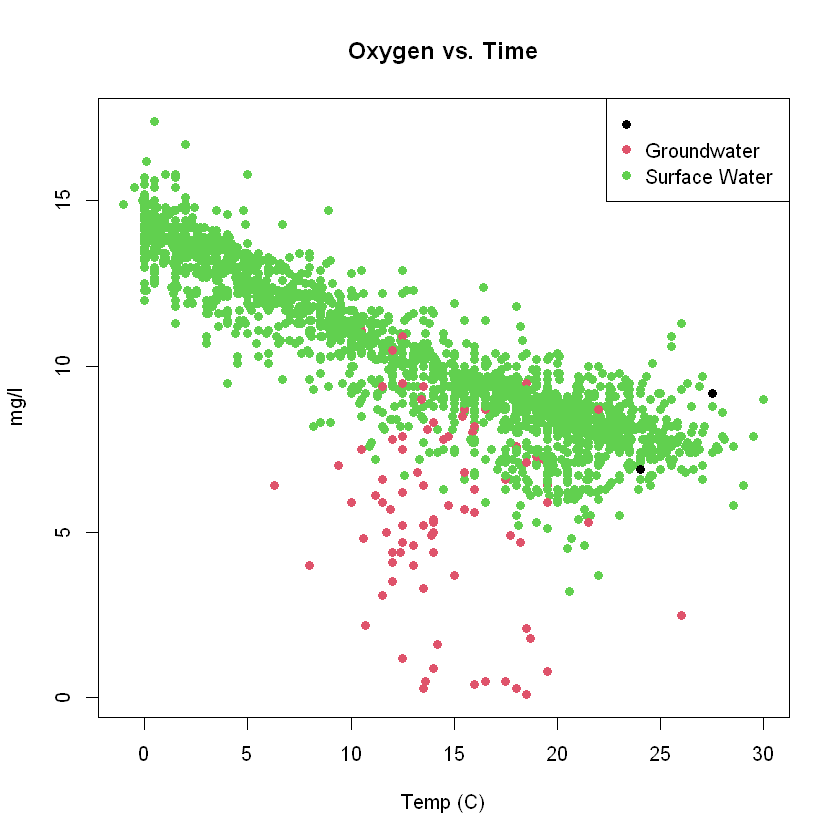

In [43]:
plot(Oxygen ~ TempC,
     data = newData,
     col = as.factor(ActivityMediaSubdivisionName),
     pch = 19,
     main = "Oxygen vs. Time",
     xlab = "Temp (C)",
     ylab = "mg/l")
legend("topright", col = 1:3, legend =  levels(as.factor(newData$ActivityMediaSubdivisionName)), pch = 19)

From here: there are so many other possible analyses you could do.  Each variable we consider will require different data cleaning and different analysis.

Welcome to the Data Cleaning Club!
